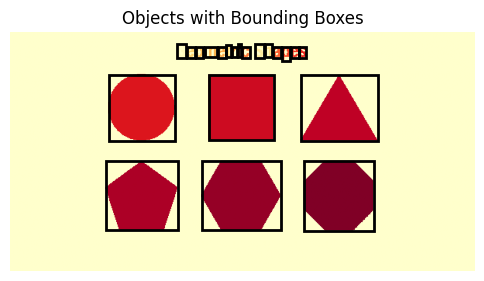

In [ ]:
#2.1 gán nhãn ảnh
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu

# Đọc ảnh và chuyển sang ảnh xám
data = Image.open('geometric.png').convert('L')
a = np.asarray(data)

# Ngưỡng hóa bằng Otsu
thres = threshold_otsu(a)
b = a > thres

# Gán nhãn các vùng đối tượng
c = label(b)

# Lưu ảnh nhãn thành file PNG (tránh lỗi mode 'I' khi lưu JPG)
iio.imsave('label_output.png', c.astype(np.uint8))  # hoặc dùng .png để lưu file an toàn

# Phân tích các thuộc tính vùng đối tượng
properties = ['Area', 'Centroid', 'BoundingBox']
d = regionprops(c)

# Vẽ hình chữ nhật bao quanh từng đối tượng
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 6))
ax.imshow(c, cmap='YlOrRd')

for l in d:
    lr, lc, ur, uc = l['BoundingBox']
    rec_width = uc - lc
    rec_height = ur - lr
    rect = mpatches.Rectangle((lc, lr), rec_width, rec_height, fill=False,
                              edgecolor='black', linewidth=2)
    ax.add_patch(rect)

plt.title("Objects with Bounding Boxes")
plt.axis('off')
plt.show()


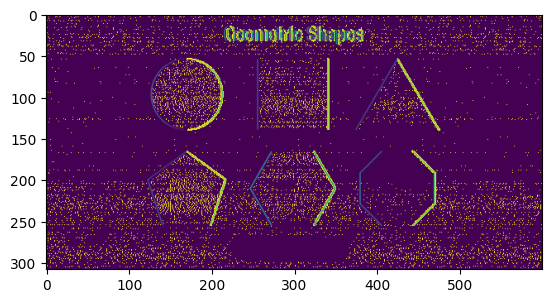

In [11]:
#2.2 Dò tìm cạnh theo chiều dọc
from PIL  import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pylab as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu

data = Image.open('geometric.png').convert('L')
bmg = abs(data - nd.shift(data, (0,1), order=0))
plt.imshow(bmg)
plt.show()


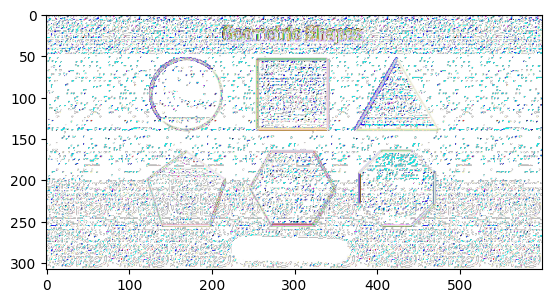

In [14]:
#2.3 Dò tìm cạnh với Sobel Fillter
from PIL import Image
import numpy as np
import cv2
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pylab as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu

data = Image.open('geometric.png')
a = nd.sobel(data, axis=0)
b = nd.sobel(data, axis=1)
bmg = abs(a) + abs(b)
plt.imshow(bmg)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-49.800000000000004..255.0].


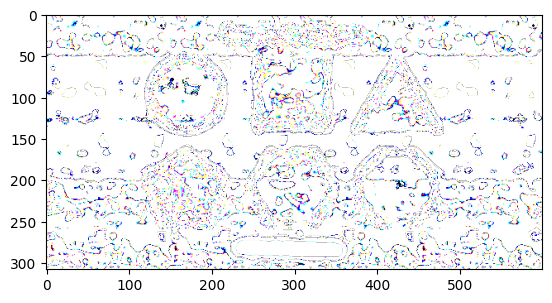

In [15]:
#2.4 Xác định góc của đối tượng
from PIL import Image
import numpy as np
import cv2
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pylab as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu

def Harris(indata, alpha=0.2):
    x = nd.sobel(indata, 0)
    y = nd.sobel(indata, 1)
    x = x ** 2
    y = y ** 2
    xy = abs(x * y)
    
    xl = nd.gaussian_filter(x, 3)
    yl = nd.gaussian_filter(y, 3)
    xy = nd.gaussian_filter(xy, 3)
    
    detC = xl * yl - 2 * xy
    trC = xl + yl
    R = detC - alpha * trC**2
    return R

data = Image.open('geometric.png')
bmg = Harris(data)
plt.imshow(bmg)
plt.show()


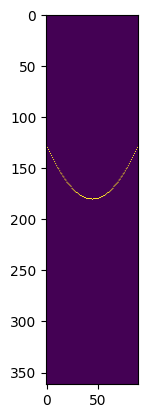

In [16]:
#2.5.1 Dò tìm đưuòng thẳng trong ảnh
import numpy as np
import cv2
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pylab as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu

def LineHough(data, gamma):
    V, H = data.shape
    R = int(np.sqrt(V * V + H * H))
    ho = np.zeros((R, 90), float)  # Hough space
    w = data + 0
    ok = 1
    theta = np.arange(90)/180.0 * np.pi
    tp = np.arange(90).astype(float)
    while ok:
        mx = w.max()
        if mx < gamma:
            ok = 0
        else:
            v, h = divmod(w.argmax(), H)
            y = V - v
            x = h
            rh = x * np.cos(theta) + y * np.sin(theta)
            for i in range(len(rh)):
                if 0 <= rh[i] < R and 0 <= tp[i] < 90:
                    ho[int(rh[i]), int(tp[i])] += mx
            w[v, h] = 0
    return ho

data = np.zeros((256, 256))
data[128, 128] = 1
bmg = LineHough(data, 0.5)
plt.imshow(bmg)
plt.show()


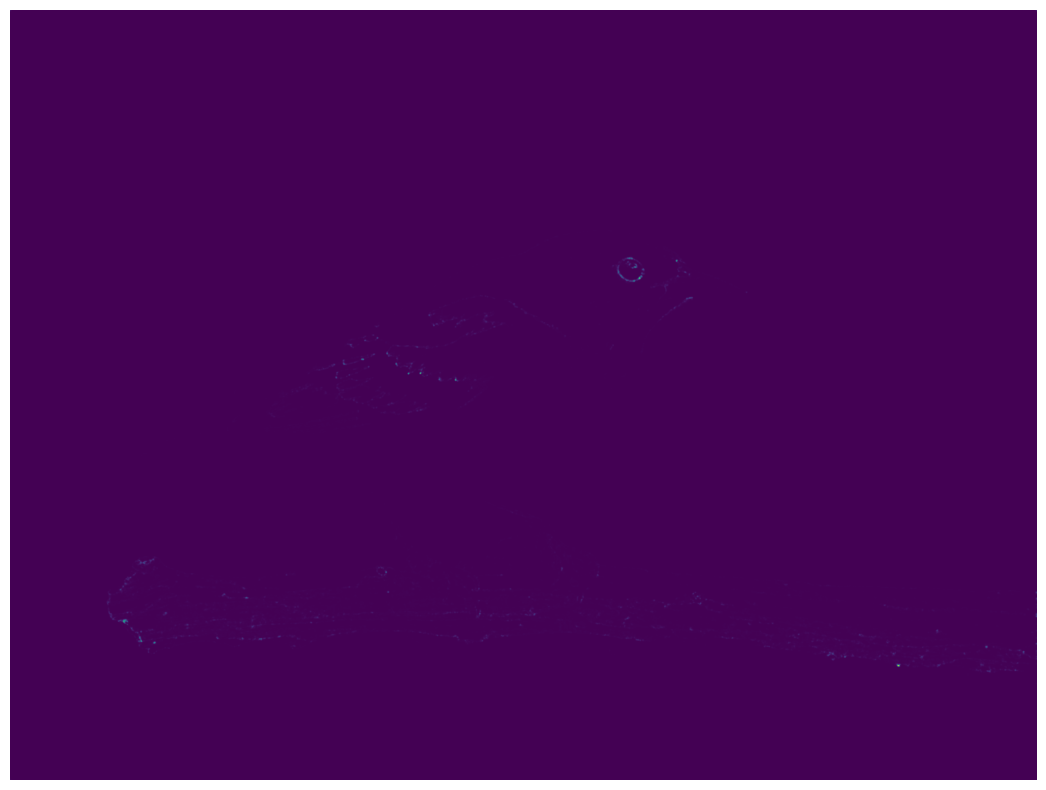

In [17]:
#2.5.2 Dò tìm đường tròn trong ảnh
from PIL import Image
import numpy as np
import cv2
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pylab as plt
import matplotlib.patches as mpatches
from skimage.feature import corner_harris
from skimage.color import rgb2gray

data = iio.imread('bird.png')
image_gray = rgb2gray(data)
coordinate = corner_harris(image_gray, k = 0.001)

plt.figure(figsize=(20,10))
plt.imshow(coordinate)
plt.axis('off')
plt.show()


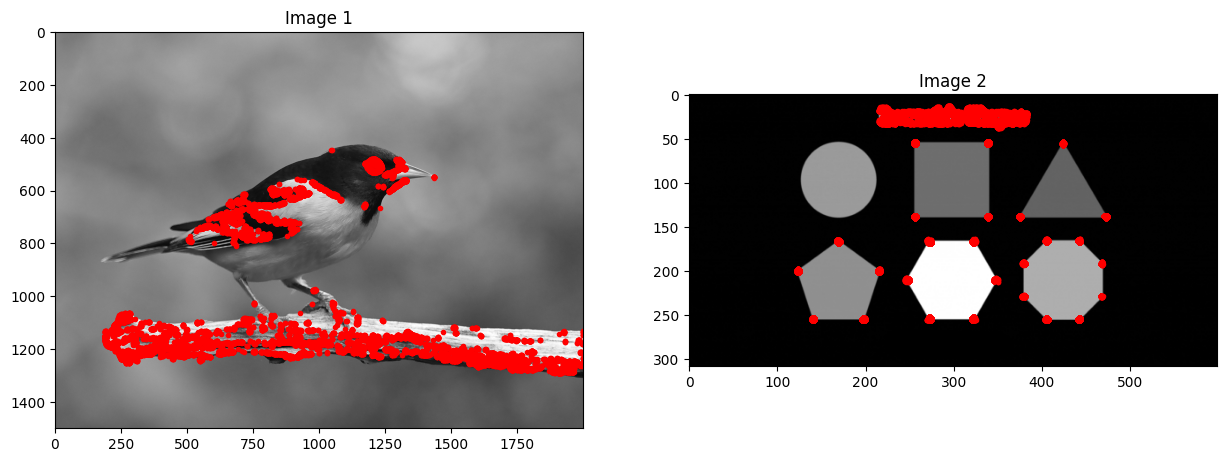

In [25]:
from PIL import Image
import numpy as np
import cv2
import imageio.v2 as iio
from skimage.color import rgb2gray
from skimage.feature import corner_harris
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

# Hàm đọc ảnh RGB và chuyển sang ảnh xám
def load_rgb_image(path):
    img = iio.imread(path)
    if img.ndim == 3 and img.shape[2] == 4:  # RGBA -> RGB
        img = img[:, :, :3]
    return rgb2gray(img)

# ---- BƯỚC 1: Đọc và chuyển sang ảnh xám ----
img1 = load_rgb_image('bird.png')
img2 = load_rgb_image('geometric.png')

# ---- BƯỚC 2: Phát hiện các điểm góc bằng Harris ----
corners1 = corner_harris(img1, k=0.01)
corners2 = corner_harris(img2, k=0.01)

# ---- BƯỚC 3: Lấy tọa độ các điểm góc có giá trị cao ----
pts1 = np.argwhere(corners1 > 0.01 * corners1.max())
pts2 = np.argwhere(corners2 > 0.01 * corners2.max())

# ---- BƯỚC 4: Trích xuất đặc trưng từ vùng lân cận (patch 5x5) ----
def extract_patch_features(image, keypoints, patch_size=5):
    features = []
    valid_pts = []
    offset = patch_size // 2
    for y, x in keypoints:
        if y - offset >= 0 and y + offset < image.shape[0] and x - offset >= 0 and x + offset < image.shape[1]:
            patch = image[y-offset:y+offset+1, x-offset:x+offset+1]
            features.append(patch.flatten())
            valid_pts.append((y, x))
    return np.array(features), np.array(valid_pts)

feat1, valid_pts1 = extract_patch_features(img1, pts1)
feat2, valid_pts2 = extract_patch_features(img2, pts2)

# ---- BƯỚC 5: Tính khoảng cách Euclidean giữa các đặc trưng ----
dists = cdist(feat1, feat2)
min_indices = np.argmin(dists, axis=1)

# ---- BƯỚC 6: Hiển thị các điểm tương ứng ----
fig, ax = plt.subplots(1, 2, figsize=(15, 10))
ax[0].imshow(img1, cmap='gray')
ax[0].set_title("Image 1")
ax[1].imshow(img2, cmap='gray')
ax[1].set_title("Image 2")

for i, pt1 in enumerate(valid_pts1):
    pt2 = valid_pts2[min_indices[i]]
    ax[0].plot(pt1[1], pt1[0], 'ro', markersize=3)
    ax[1].plot(pt2[1], pt2[0], 'ro', markersize=3)

plt.show()
